In [1]:
import dask.dataframe as dd

df = dd.read_csv("taxi_trip_data.csv")
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
0,2,2018-03-29 13:37:13,2018-03-29 14:17:01,1,18.15,3,N,1,70.0,0.0,0.0,16.16,10.50,0.3,96.96,161,1
1,2,2018-03-29 13:37:18,2018-03-29 14:15:33,1,4.59,1,N,1,25.0,0.0,0.5,5.16,0.00,0.3,30.96,13,230
2,2,2018-03-29 13:26:57,2018-03-29 13:28:03,1,0.30,1,N,1,3.0,0.0,0.5,0.76,0.00,0.3,4.56,231,231
3,2,2018-03-29 13:07:48,2018-03-29 14:03:05,2,16.97,1,N,1,49.5,0.0,0.5,5.61,5.76,0.3,61.67,231,138
4,2,2018-03-29 14:19:11,2018-03-29 15:19:59,5,14.45,1,N,1,45.5,0.0,0.5,10.41,5.76,0.3,62.47,87,138


In [2]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
0,2,2018-03-29 13:37:13,2018-03-29 14:17:01,1,18.15,3,N,1,70.0,0.0,0.0,16.16,10.50,0.3,96.96,161,1
1,2,2018-03-29 13:37:18,2018-03-29 14:15:33,1,4.59,1,N,1,25.0,0.0,0.5,5.16,0.00,0.3,30.96,13,230
2,2,2018-03-29 13:26:57,2018-03-29 13:28:03,1,0.30,1,N,1,3.0,0.0,0.5,0.76,0.00,0.3,4.56,231,231
3,2,2018-03-29 13:07:48,2018-03-29 14:03:05,2,16.97,1,N,1,49.5,0.0,0.5,5.61,5.76,0.3,61.67,231,138
4,2,2018-03-29 14:19:11,2018-03-29 15:19:59,5,14.45,1,N,1,45.5,0.0,0.5,10.41,5.76,0.3,62.47,87,138


In [3]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'trip_distance', 'rate_code', 'store_and_fwd_flag', 'payment_type',
       'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'imp_surcharge', 'total_amount', 'pickup_location_id',
       'dropoff_location_id'],
      dtype='object')

In [4]:
df.dtypes

vendor_id                        int64
pickup_datetime        string[pyarrow]
dropoff_datetime       string[pyarrow]
passenger_count                  int64
trip_distance                  float64
rate_code                        int64
store_and_fwd_flag     string[pyarrow]
payment_type                     int64
fare_amount                    float64
extra                          float64
mta_tax                        float64
tip_amount                     float64
tolls_amount                   float64
imp_surcharge                  float64
total_amount                   float64
pickup_location_id               int64
dropoff_location_id              int64
dtype: object

In [5]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [6]:
df = df.dropna()
df = df.drop_duplicates()

In [7]:
print("Total Rows:", len(df))

Total Rows: 9392429


In [8]:
print("Average Fare:", df["fare_amount"].mean().compute())

Average Fare: 31.63611965765193


In [9]:
print(df["passenger_count"].value_counts().compute())

passenger_count
0      85779
7        196
3     392020
2    1417209
9        140
1    6629109
5     430615
6     253624
8        160
4     183577
Name: count, dtype: int64


In [10]:
df.nlargest(10, "fare_amount").compute()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
119780,1,2018-07-17 18:52:13,2018-07-17 18:58:09,1,0.0,1,N,3,398460.05,61.61,0.0,0.0,0.0,0.3,398521.96,100,161
139813,1,2018-03-30 19:53:59,2018-03-30 20:03:44,2,1.4,1,N,3,214748.44,1.00,0.5,0.0,0.0,0.3,214750.24,107,4
50544,1,2018-11-22 02:41:09,2018-11-22 02:42:35,1,0.3,1,N,2,187436.46,0.50,0.5,0.0,0.0,0.3,187437.76,246,246
310661,1,2018-07-01 15:03:47,2018-07-01 15:06:14,1,0.2,1,N,4,99618.22,0.00,0.5,0.0,0.0,0.3,99619.02,48,163
432002,1,2018-12-21 16:06:28,2018-12-21 16:06:28,0,0.0,99,N,1,38301.78,0.00,0.0,0.0,0.0,0.0,38301.78,264,264
266124,1,2018-12-17 16:09:31,2018-12-17 16:09:31,0,0.0,99,N,1,31237.77,0.00,0.0,0.0,0.0,0.0,31237.77,264,264
55216,1,2018-12-27 10:40:30,2018-12-27 10:40:30,0,0.0,99,N,1,22319.33,0.00,0.0,0.0,0.0,0.0,22319.33,264,264
241970,1,2018-12-27 10:39:01,2018-12-27 10:39:01,0,0.0,99,N,1,20589.88,0.00,0.0,0.0,0.0,0.0,20589.88,264,264
349013,1,2018-12-27 10:37:28,2018-12-27 10:37:28,0,0.0,99,N,1,20416.91,0.00,0.0,0.0,0.0,0.0,20416.91,264,264
406141,1,2018-12-27 10:39:47,2018-12-27 10:39:47,0,0.0,99,N,1,19269.65,0.00,0.0,0.0,0.0,0.0,19269.65,264,264


In [11]:
print("Average Distance:", df["trip_distance"].mean().compute())

Average Distance: 8.838213041589134


In [12]:
print("Partitions before:", df.npartitions)

df = df.repartition(npartitions=8)

print("Partitions after:", df.npartitions)

Partitions before: 22
Partitions after: 8


In [13]:
import time

start = time.time()

df["passenger_count"].value_counts().compute()

end = time.time()

print("Execution Time:", end - start)

Execution Time: 30.17592453956604


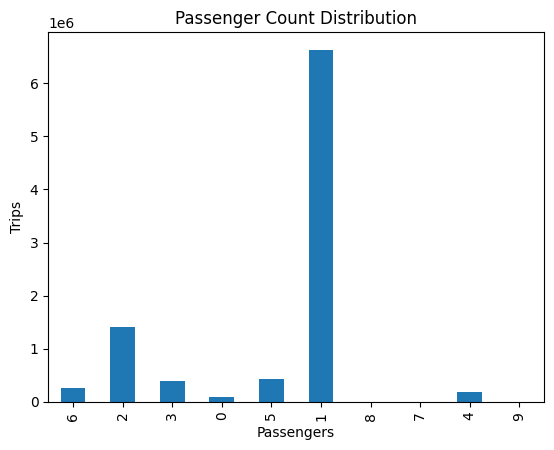

In [14]:
import matplotlib.pyplot as plt

data = df["passenger_count"].value_counts().compute()

data.plot(kind="bar")

plt.title("Passenger Count Distribution")
plt.xlabel("Passengers")
plt.ylabel("Trips")
plt.show()

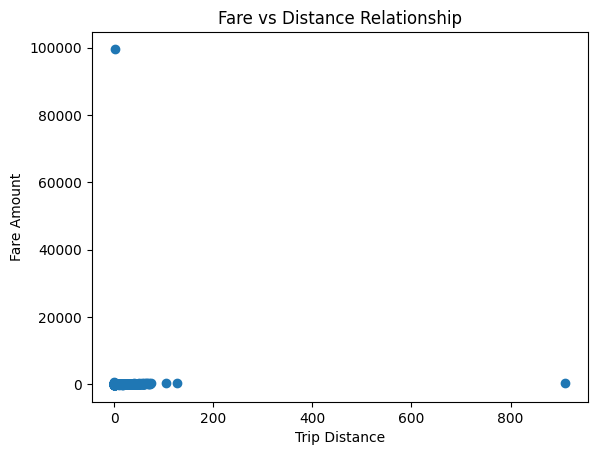

In [16]:
import matplotlib.pyplot as plt

sample = df[["trip_distance", "fare_amount"]].dropna().sample(frac=0.01).compute()

plt.scatter(sample["trip_distance"], sample["fare_amount"])
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Fare vs Distance Relationship")
plt.show()

In [17]:
high_fare = df[df["fare_amount"] > 200].compute()
print("High fare trips:", len(high_fare))
high_fare.head()

High fare trips: 6233


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
30395,1,2018-12-30 10:33:47,2018-12-30 12:06:04,3,70.10,5,N,1,231.0,0.0,0.0,10.0,24.02,0.3,265.32,132,265
56728,2,2018-02-05 18:05:47,2018-02-05 22:05:58,1,79.01,1,N,1,250.0,1.0,0.5,28.0,20.16,0.3,299.96,117,117
117509,1,2018-03-11 04:07:07,2018-03-11 04:51:04,1,38.80,5,N,3,276.5,0.0,0.0,0.0,1.75,0.3,278.55,140,265
118981,2,2018-08-24 16:57:05,2018-08-24 16:57:17,1,0.00,5,N,2,327.0,0.0,0.0,0.0,0.00,0.3,327.30,226,226
144336,2,2018-06-17 17:51:34,2018-06-17 19:15:16,2,73.65,5,N,1,443.0,0.0,0.5,40.0,7.51,0.3,491.31,70,265


In [18]:
peak = df["passenger_count"].value_counts().compute()
print(peak)

passenger_count
6     253624
2    1417209
3     392020
0      85779
5     430615
1    6629109
8        160
7        196
4     183577
9        140
Name: count, dtype: int64


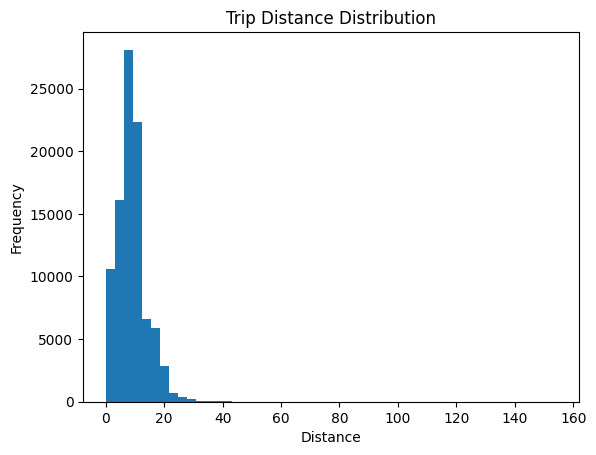

In [19]:
dist = df["trip_distance"].sample(frac=0.01).compute()

plt.hist(dist, bins=50)
plt.title("Trip Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

In [20]:
df["fare_per_km"] = df["fare_amount"] / df["trip_distance"]

efficiency = df["fare_per_km"].mean().compute()
print("Average Fare per Distance:", efficiency)

Average Fare per Distance: 0.0


In [21]:
df.nlargest(5, "fare_amount").compute()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,fare_per_km
119780,1,2018-07-17 18:52:13,2018-07-17 18:58:09,1,0.0,1,N,3,398460.05,61.61,0.0,0.0,0.0,0.3,398521.96,100,161,inf
139813,1,2018-03-30 19:53:59,2018-03-30 20:03:44,2,1.4,1,N,3,214748.44,1.00,0.5,0.0,0.0,0.3,214750.24,107,4,1.533917e+05
50544,1,2018-11-22 02:41:09,2018-11-22 02:42:35,1,0.3,1,N,2,187436.46,0.50,0.5,0.0,0.0,0.3,187437.76,246,246,6.247882e+05
310661,1,2018-07-01 15:03:47,2018-07-01 15:06:14,1,0.2,1,N,4,99618.22,0.00,0.5,0.0,0.0,0.3,99619.02,48,163,4.980911e+05
432002,1,2018-12-21 16:06:28,2018-12-21 16:06:28,0,0.0,99,N,1,38301.78,0.00,0.0,0.0,0.0,0.0,38301.78,264,264,inf


In [22]:
anomaly = df[(df["trip_distance"] < 2) & (df["fare_amount"] > 50)].compute()
anomaly.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,fare_per_km
5982,1,2018-09-18 23:35:25,2018-09-18 23:35:41,1,0.00,5,N,1,63.00,0.0,0.0,12.65,0.0,0.3,75.95,237,237,inf
6325,2,2018-04-10 14:37:19,2018-04-10 14:37:21,1,0.01,5,N,1,68.00,0.0,0.5,10.00,0.0,0.3,78.80,88,88,6800.00
6463,2,2018-12-27 18:17:38,2018-12-27 18:17:41,4,0.50,5,N,1,62.76,0.0,0.0,10.00,0.0,0.3,73.06,264,216,125.52
10285,2,2018-12-28 15:29:30,2018-12-28 15:29:33,1,0.00,5,N,1,74.36,0.0,0.0,18.66,0.0,0.3,93.32,113,113,inf
12548,2,2018-12-06 19:47:34,2018-12-06 19:47:37,1,0.00,5,N,1,110.00,0.0,0.5,10.00,0.0,0.3,120.80,264,132,inf


In [23]:
import time

# Before repartition
start = time.time()
df["passenger_count"].value_counts().compute()
print("Time before:", time.time() - start)

# After repartition
df = df.repartition(npartitions=8)

start = time.time()
df["passenger_count"].value_counts().compute()
print("Time after:", time.time() - start)

Time before: 36.15760135650635
Time after: 31.396679878234863
